# [LAB-06] 10. Stacked Bar Plot - 연습문제

## #01. 준비작업

### 1. 패키지 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import pivot_table, CategoricalDtype
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("diamonds_qtcheck")
origin

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000
...,...,...,...,...,...,...,...,...,...,...
53789,2757,0.720,Ideal,D,SI1,5.750,5.760,3.500,60.800,57.000
53790,2757,0.720,Good,D,SI1,5.690,5.750,3.610,63.100,55.000
53791,2757,0.700,Very Good,D,SI1,5.660,5.680,3.560,62.800,60.000
53792,2757,0.860,Premium,H,SI2,6.150,6.120,3.740,61.000,58.000


## #02. 데이터 시각화

/Users/leekh/hossam-ml/helpers/my_plot.py:589: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)
/Users/leekh/hossam-ml/helpers/my_plot.py:589: FutureWarning: The provided callable <function mean at 0x10ac9d800> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


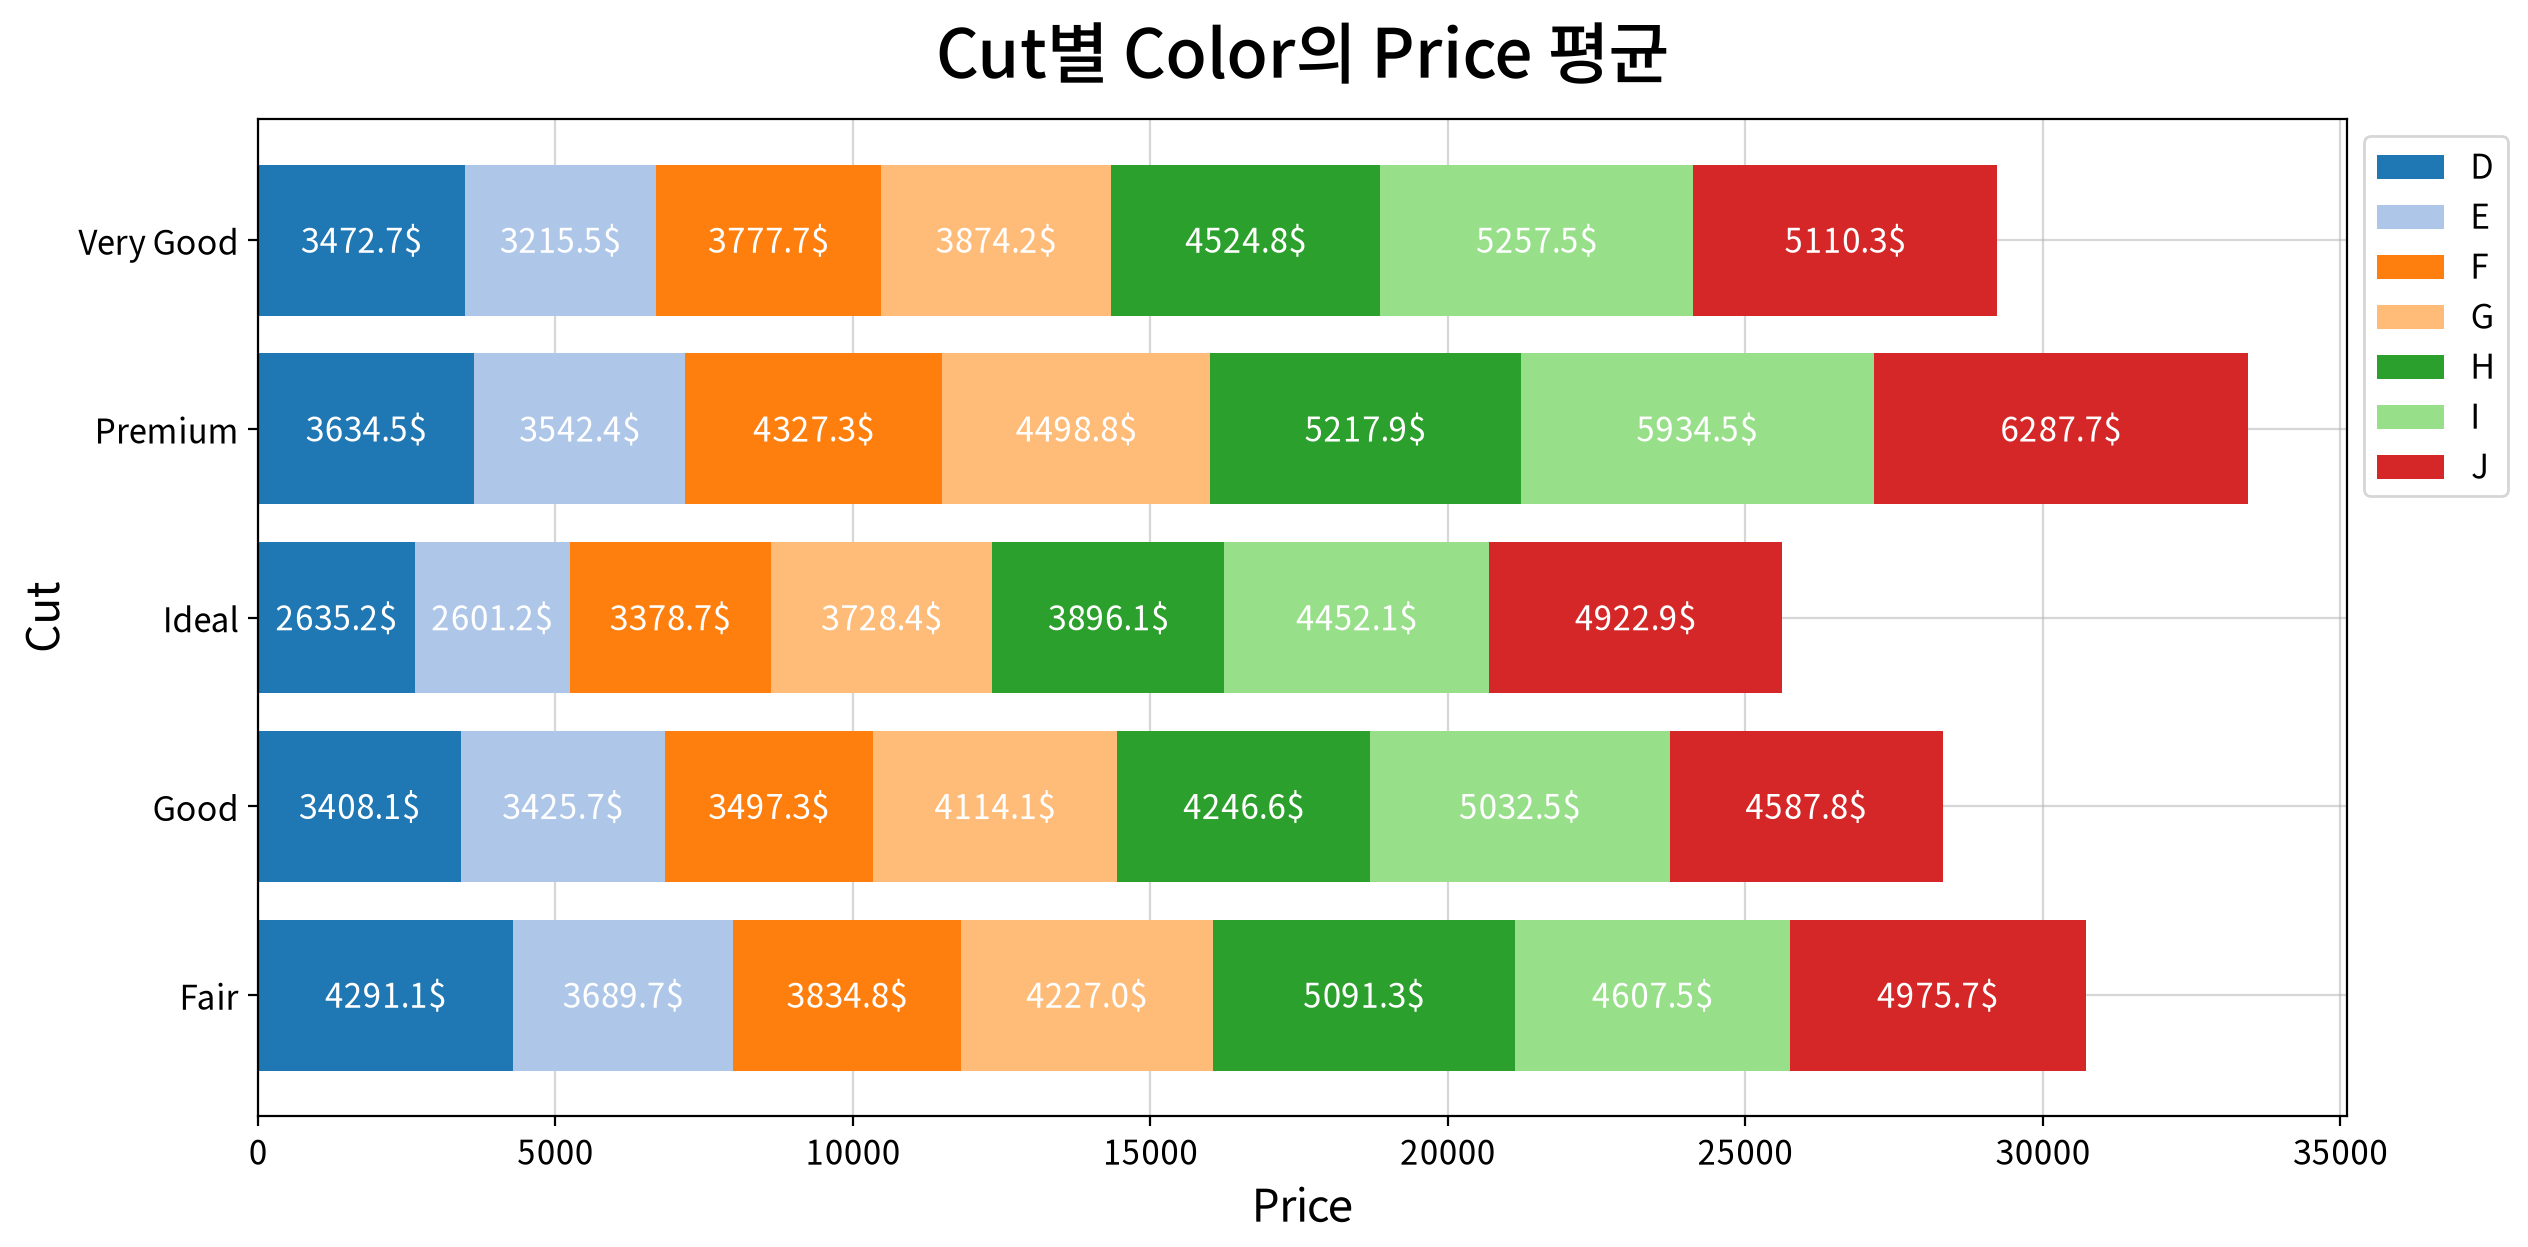

In [3]:
my_plot.stackplot(data=origin,
                x="cut",
                y="price",
                hue="color",
                aggfunc=np.mean,
                orient='h',
                text_format="{:.1f}$",
                palette="tab20",
                title="Cut별 Color의 Price 평균",
                xlabel="Price",
                ylabel="Cut")

## 문제 풀이

### 문제 1

Color D(가장 좋은 색상 등급)의 평균 가격이 가장 높게 나타나는 Cut 등급은?

- **정답**: Fair
- **해설**: Color D의 평균 가격은 Fair Cut에서 4291.1$로 가장 높으며, 두 번째로 높은 Premium Cut(3634.5$)보다 약 657$ 더 비싸다. "가장 좋은 컷(Ideal) + 가장 좋은 색상(D) = 가장 비쌈"이라는 직관과 반대되는 결과로, Fair Cut 등급으로 가공되는 D Color 다이아몬드들이 상대적으로 큰 캐럿대에 분포해 있어 평균 가격을 끌어올리기 때문으로 해석된다.

### 문제 2

5개 Cut 등급 중 4개에서는 J 또는 I Color가 가장 높은 평균 가격을 보이지만, 유일하게 다른 Color 등급이 1위를 차지하는 Cut이 존재한다. 해당 Cut 등급에서 평균 가격이 가장 높은 Color는?

- **정답**: H
- **해설**: Fair Cut만 예외적으로 H Color(5091.3$)가 가장 높은 평균 가격을 기록한다. 참고로 Very Good과 Good은 I, Premium과 Ideal은 J Color가 최고가이다. 일반적으로 등급이 낮은 Color일수록 큰 캐럿에 더 많이 분포하기 때문에 평균 가격이 높게 나타나는 경향이 있는데, Fair Cut에서는 이 패턴이 H에서 정점을 찍고 I, J로 갈수록 다시 낮아지는 비단조(non-monotonic) 형태를 보인다.

### 문제 3

대부분의 Color 등급에서는 Ideal Cut의 평균 가격이 가장 낮지만, J Color에서는 Ideal보다 평균 가격이 더 낮은 Cut 등급이 존재한다. 해당 Cut 등급은?

- **정답**: Good
- **해설**: J Color에서 Good Cut의 평균 가격은 4587.8$로, Ideal Cut의 4922.9$보다 약 335$ 더 낮다. D~I Color에서는 모두 Ideal이 최저가를 차지하지만, 유일하게 J Color만 Good Cut이 최저가가 되는 예외적인 패턴이다. 동일 색상 등급 내에서도 Cut에 따라 평균 가격 순위가 달라질 수 있음을 보여준다.